# Phase 7: Neural Network Analysis

This phase focuses on analyzing the learning behavior of the Neural Network model by visualizing the training loss curve over iterations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/Data-Driven-Energy-Project')

Mounted at /content/drive


In [4]:
df = pd.read_csv("data/energy_efficiency.csv", encoding='latin1')

df.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Distribution",
    "Heating_Load",
    "Cooling_Load"
]
df = df.dropna()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(["Heating_Load", "Cooling_Load"], axis=1)
y = df["Heating_Load"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

TRAIN NEURAL NETWORK WITH LOSS TRACKING

In [6]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(
    hidden_layer_sizes=(100,100),
    max_iter=300,
    random_state=42,
    verbose=True
)

nn.fit(X_train_scaled, y_train)

Iteration 1, loss = 294.87843003
Iteration 2, loss = 283.70565332
Iteration 3, loss = 272.56696467
Iteration 4, loss = 261.10445450
Iteration 5, loss = 248.69214537
Iteration 6, loss = 235.15577462
Iteration 7, loss = 219.56861822
Iteration 8, loss = 202.33644925
Iteration 9, loss = 183.68133623
Iteration 10, loss = 163.06691993
Iteration 11, loss = 141.71671416
Iteration 12, loss = 120.16538336
Iteration 13, loss = 98.74671436
Iteration 14, loss = 78.79762399
Iteration 15, loss = 62.04264259
Iteration 16, loss = 47.49849341
Iteration 17, loss = 36.76644859
Iteration 18, loss = 29.49938826
Iteration 19, loss = 25.02205489
Iteration 20, loss = 22.57810768
Iteration 21, loss = 21.23989277
Iteration 22, loss = 20.07224013
Iteration 23, loss = 18.80028844
Iteration 24, loss = 17.58470242
Iteration 25, loss = 16.49567151
Iteration 26, loss = 15.62038210
Iteration 27, loss = 14.93012561
Iteration 28, loss = 14.38011582
Iteration 29, loss = 13.88269394
Iteration 30, loss = 13.51388945
Iterati

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=300, random_state=42,
             verbose=True)

EXTRACT LOSS CURVE

In [7]:
loss_values = nn.loss_curve_


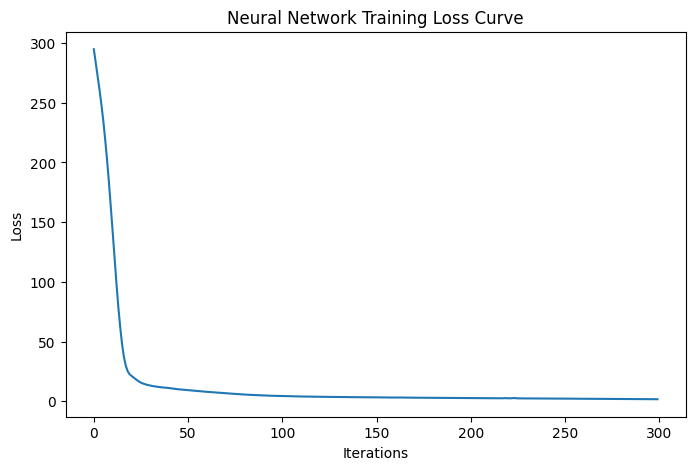

In [8]:
plt.figure(figsize=(8,5))
plt.plot(loss_values)

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Neural Network Training Loss Curve")

plt.savefig("outputs/graphs/14_nn_loss_curve.png")

plt.show()

The neural network model was analyzed using the training loss curve. The loss decreases steadily over iterations, indicating that the model is learning effectively. The curve stabilizes after several iterations, showing convergence and good training performance.